# SHAP — SHapley Additive exPlanations

**SHAP** is a unified framework for explaining individual model predictions, grounded in cooperative game theory. For a single prediction $f(x)$, Shapley values fairly distribute credit among all features:

$$f(x) = \phi_0 + \sum_{j=1}^{p} \phi_j$$

where $\phi_0$ is the **base value** (mean model output over the training set) and $\phi_j$ is the **SHAP value** for feature $j$ — how much that feature added to or subtracted from $\phi_0$ to produce the actual prediction.

Shapley values satisfy four axioms that make them uniquely fair:

| Axiom | Meaning |
|---|---|
| **Efficiency** | SHAP values sum exactly to $f(x) - \phi_0$ |
| **Symmetry** | Features with identical contributions get equal credit |
| **Dummy** | A feature that never changes the prediction gets SHAP = 0 |
| **Additivity** | SHAP values for an ensemble equal the sum of values for each tree |

**Why SHAP over simpler importance measures?**
- Gini / permutation importance → one score per feature, no direction, no per-sample detail
- SHAP → signed score *per prediction*, aggregates faithfully to global summaries, works for any model

**This notebook covers:**
1. Dataset and model setup
2. TreeExplainer and SHAP value computation
3. Summary plots — dot/beeswarm and violin (classic API)
4. Bar plot — global feature importance
5. Waterfall plots — four representative cases (TP / TN / FP / FN)
6. Force plots — four representative cases (TP / TN / FP / FN)
7. Dependence plots — feature effects and interactions
8. Decision plot — prediction paths
9. Heatmap — dataset-level SHAP matrix

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from fairlearn.datasets import fetch_diabetes_hospital
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import spearmanr

plt.style.use('dark_background')
pd.set_option('display.max_columns', 100)

## Dataset — Diabetes Hospital Readmission

We use the **Diabetes Hospital Readmission** dataset from the UCI Machine Learning Repository (loaded via `fairlearn`). It contains ten years of clinical care records from 130 US hospitals.

| Property | Value |
|---|---|
| Samples | ~101,766 (we use a stratified sample) |
| Features | 22 (after dropping leaky target-derived columns) |
| Target | `readmit_30_days`: 1 = readmitted within 30 days, 0 = not |
| Class balance | ~89% negative, ~11% positive — notable imbalance |

**Feature types:**
- *Numeric*: time in hospital, number of lab procedures, medications, diagnoses, etc.
- *Categorical*: race, gender, age group, diagnosis codes, medication regimens, etc.

We encode all categorical features with `OrdinalEncoder` (ordinal codes are fine for tree-based models, which split on thresholds rather than distances). The encoder is fit on the training fold only to prevent any data leakage.

In [2]:
data = fetch_diabetes_hospital(as_frame=True)

n_samp_per_class = 1000
target = 'readmit_30_days'  # binary target (0/1)

df = pd.concat([data.data, data.target], axis=1)
df


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'30 years or younger',Other,Referral,1,Other,41,0,1,Diabetes,1,None,None,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,'30 years or younger','Discharged to Home',Emergency,3,Missing,59,0,18,Other,9,None,None,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,'30 years or younger','Discharged to Home',Emergency,2,Missing,11,5,13,Other,6,None,None,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,2,Missing,44,1,16,Other,7,None,None,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,1,Missing,51,0,8,Other,5,None,None,Steady,Ch,Yes,False,False,False,False,False,NO,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,'Over 60 years',Other,Emergency,3,Missing,51,0,16,Diabetes,9,None,>8,Down,Ch,Yes,True,False,False,False,False,>30,1,0
101762,AfricanAmerican,Female,'Over 60 years',Other,Other,5,Missing,33,3,18,Other,9,None,None,Steady,No,Yes,True,False,False,True,False,NO,0,0
101763,Caucasian,Male,'Over 60 years','Discharged to Home',Emergency,1,Missing,53,0,9,Other,13,None,None,Down,Ch,Yes,True,False,False,False,True,NO,0,0
101764,Caucasian,Female,'Over 60 years',Other,Emergency,10,Other,45,2,21,Other,9,None,None,Up,Ch,Yes,True,False,False,True,False,NO,0,0


In [3]:

vc = df[target].value_counts()
print(f'Class distribution:\n{vc}\n')
df1 = df[df[target] == 0].sample(n_samp_per_class, random_state=42)
df2 = df[df[target] == 1].sample(n_samp_per_class, random_state=42)
df = pd.concat([df1, df2], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Balanced class distribution:\n{df[target].value_counts()}\n')

# Drop columns derived from the target (would be leakage)
X = df.drop(columns=['readmitted', 'readmit_binary', 'readmit_30_days'])
y = df[target]   # readmit_30_days: binary 0/1

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# get categorical dummies for all categorical features
X_cat = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(int)
X = pd.concat([X[num_cols], X_cat], axis=1)

feature_names = X.columns.tolist()
n_feat = len(feature_names)

X


Class distribution:
readmit_30_days
0    90409
1    11357
Name: count, dtype: int64

Balanced class distribution:
readmit_30_days
1    1000
0    1000
Name: count, dtype: int64



,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown,gender_Male,age_'30-60 years',age_'Over 60 years',discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Missing,medical_specialty_Other,primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,primary_diagnosis_Other,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,8,10,2,19,5,8,10,2,19,5,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
1,6,53,0,13,9,6,53,0,13,9,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0
2,5,44,0,11,7,5,44,0,11,7,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0
3,3,65,2,23,9,3,65,2,23,9,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0
4,2,37,0,10,7,2,37,0,10,7,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,7,43,0,12,6,7,43,0,12,6,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,0,1,0,0,0,0
1996,2,10,0,12,5,2,10,0,12,5,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,1,1,0,1,0,1,0
1997,4,45,3,44,5,4,45,3,44,5,0,1,0,0,0,1,1,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0
1998,3,49,0,21,6,3,49,0,21,6,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,1,0


## Classification Model

We train a **Random Forest** classifier with `class_weight='balanced'` to compensate for the class imbalance (~11% positives). `TreeExplainer` in the SHAP library is optimized for tree ensembles — it computes exact Shapley values by exploiting the tree structure in polynomial time, far faster than model-agnostic Kernel SHAP.

Any tree-based model works with `TreeExplainer`: `RandomForestClassifier`, `GradientBoostingClassifier`, `XGBClassifier`, `LGBMClassifier`, `CatBoostClassifier`.

In [4]:
# Train/test split (fit encoder on train only)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Random Over Sampler
# This will duplicate minority samples until they match the majority count
ros = RandomOverSampler(random_state=42)

# 2. Fit and resample ONLY the training data
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# 3. Define and fit the model
# We remove class_weight='balanced' because the training data is now 50/50
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# 4. Predict on the original test set
y_pred = model.predict(X_test)

# 5. Output results
print(f"Original shape: {y_train.value_counts().to_dict()}")
print(f"Resampled shape: {y_train_res.value_counts().to_dict()}\n")

print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

Original shape: {1: 800, 0: 800}
Resampled shape: {1: 800, 0: 800}

                precision    recall  f1-score   support

Not Readmitted       0.56      0.54      0.55       200
    Readmitted       0.55      0.57      0.56       200

      accuracy                           0.56       400
     macro avg       0.56      0.55      0.55       400
  weighted avg       0.56      0.56      0.55       400



## SHAP Setup — TreeExplainer

`shap.TreeExplainer` computes exact Shapley values for tree ensembles. For binary classification in SHAP ≥ 0.44, both the old and new APIs return values for **both classes** in a single array — the last axis indexes the class.

We focus on **class 1** (readmitted within 30 days) throughout.

| Interface | Returns | Shape | Used for |
|---|---|---|---|
| `explainer.shap_values(X)` | NumPy array | `(n, p, 2)` | `summary_plot`, `dependence_plot`, `decision_plot`, `force_plot` |
| `explainer(X)` | `Explanation` object | `(n, p, 2)` | `plots.bar`, `plots.beeswarm`, `plots.waterfall`, `plots.heatmap` |

> **Note:** Feeding a **DataFrame** (rather than a NumPy array) to `explainer(X)` automatically propagates column names into the `Explanation` object — required by `plots.heatmap` and recommended for all new-API plots.

In [6]:
explainer = shap.TreeExplainer(model)

# Old API — returns ndarray (n_test, n_features, 2) in SHAP >= 0.44
# Index last axis for class: [:, :, 0] = class 0, [:, :, 1] = class 1
sv_raw   = explainer.shap_values(X_test)   # (n_test, n_features, 2)
sv       = sv_raw[:, :, 1]                  # class 1 → (n_test, n_features)
base_val = explainer.expected_value[1]

# New API — feed DataFrame so feature names propagate into the Explanation object
sv_exp = explainer(X_test)                  # Explanation (n_test, n_features, 2)
sv_new = sv_exp[:, :, 1]                    # Explanation for class 1

print(f'SHAP matrix shape (old API):  {sv.shape}')
print(f'Base value E[f(x)]:           {base_val:.4f}')
print(f'\nSanity check (first test sample):')
print(f'  base_val + sum(SHAP values) = {base_val + sv[0].sum():.4f}')
print(f'  model predict_proba class 1 = {model.predict_proba(X_test.iloc[:1])[0, 1]:.4f}')

SHAP matrix shape (old API):  (400, 46)
Base value E[f(x)]:           0.4998

Sanity check (first test sample):
  base_val + sum(SHAP values) = 0.5700
  model predict_proba class 1 = 0.5700


## 3. Summary Plots — Dot/Beeswarm and Violin (Classic API)

The classic `shap.summary_plot` function offers two variants:

- **Dot** — identical to the beeswarm; each dot is one sample
- **Violin** — kernel density estimation of the SHAP distribution per feature; cleaner when sample count is large and dots heavily overlap

Both plots use the same red–blue color scale mapping raw feature values.

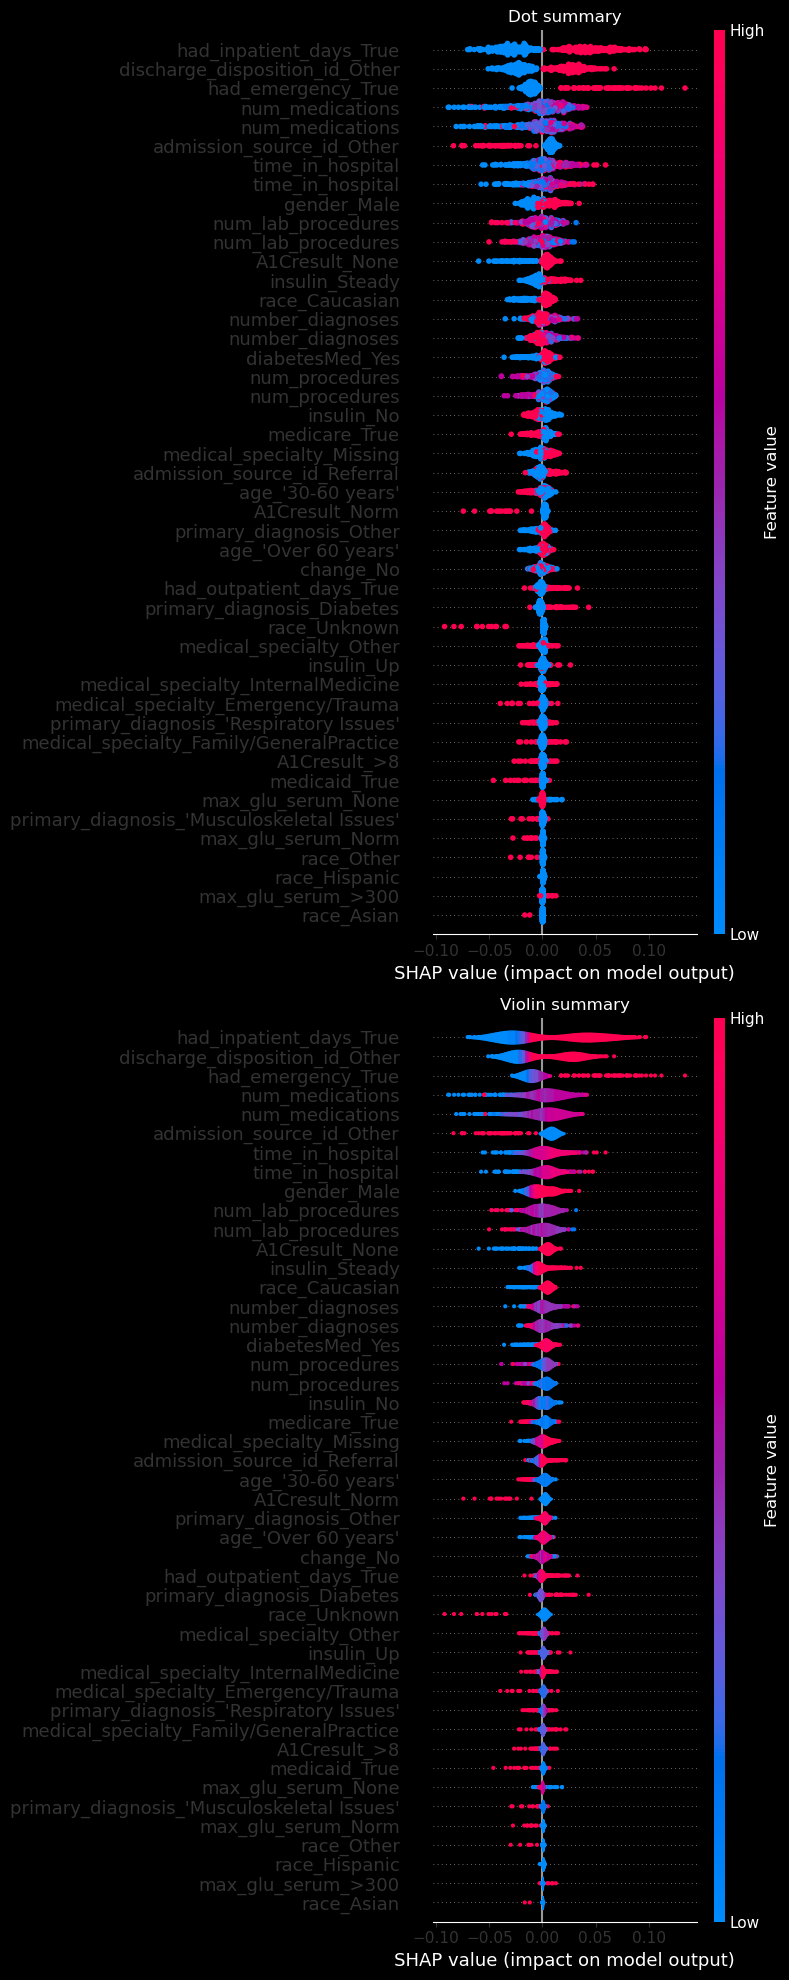

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(25, 25))

plt.sca(axes[0])
shap.summary_plot(sv, X_test, feature_names=feature_names,
                  max_display=n_feat, plot_type='dot', show=False)
axes[0].set_title('Dot summary')

plt.sca(axes[1])
shap.summary_plot(sv, X_test, feature_names=feature_names,
                  max_display=n_feat, plot_type='violin', show=False)
axes[1].set_title('Violin summary')

plt.tight_layout()
plt.show()

## 4. Bar Plot — Global Feature Importance

The bar plot shows **mean |SHAP|** for each feature — the average magnitude of that feature's contribution across all test samples. This is the SHAP analogue of Gini importance, but unbiased toward high-cardinality features and computed from the actual Shapley attribution rather than split statistics.

Features with mean |SHAP| near zero contributed almost nothing on average — they are good candidates for removal without harming predictive accuracy.

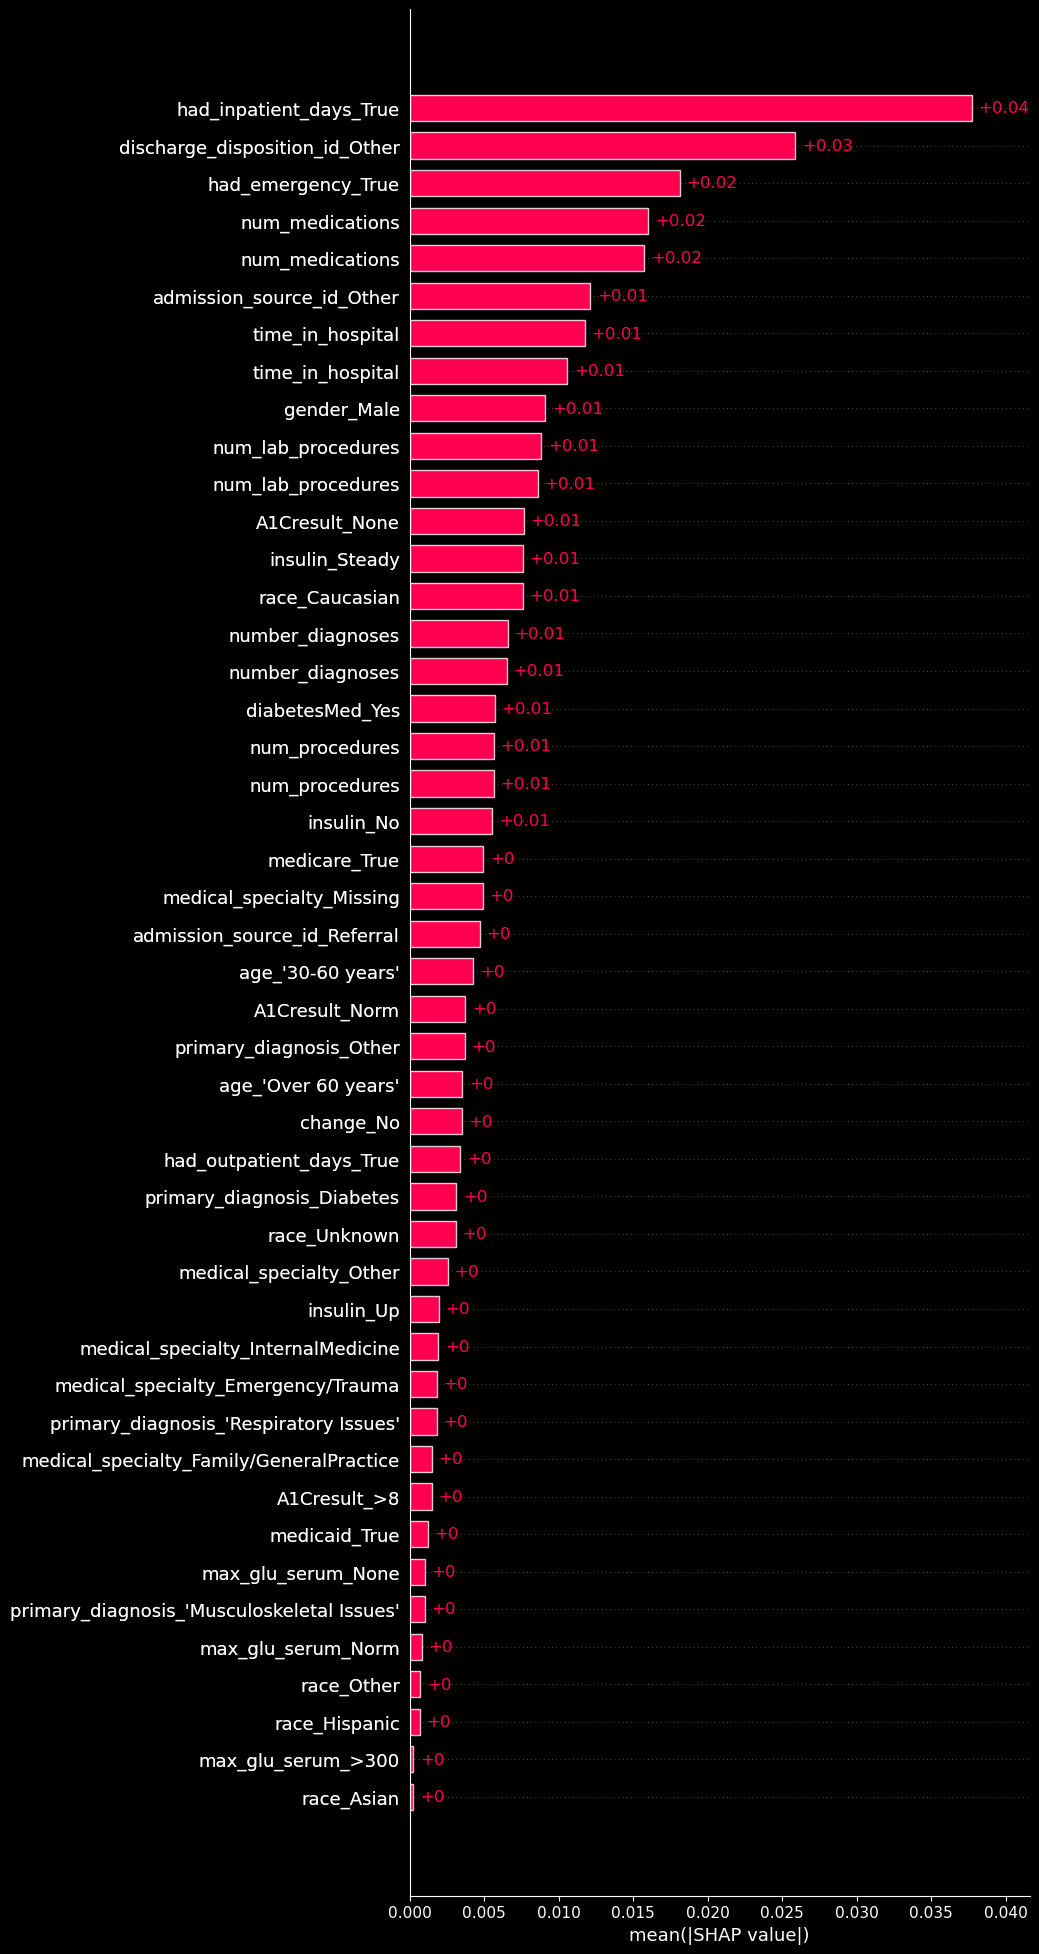

In [8]:
shap.plots.bar(sv_new, max_display=n_feat)

## 5. Waterfall Plots — Four Representative Cases

The waterfall plot explains a *single* prediction step by step. Starting from the base value $E[f(x)]$, each bar extends left (negative — pushes toward *not* readmitted) or right (positive — pushes toward readmission within 30 days). The final value is the model's output for that patient.

We display waterfall plots for all four classification outcomes — True Positive, True Negative, False Positive, and False Negative — so we can compare the feature contributions that drive correct predictions against those behind each error type.

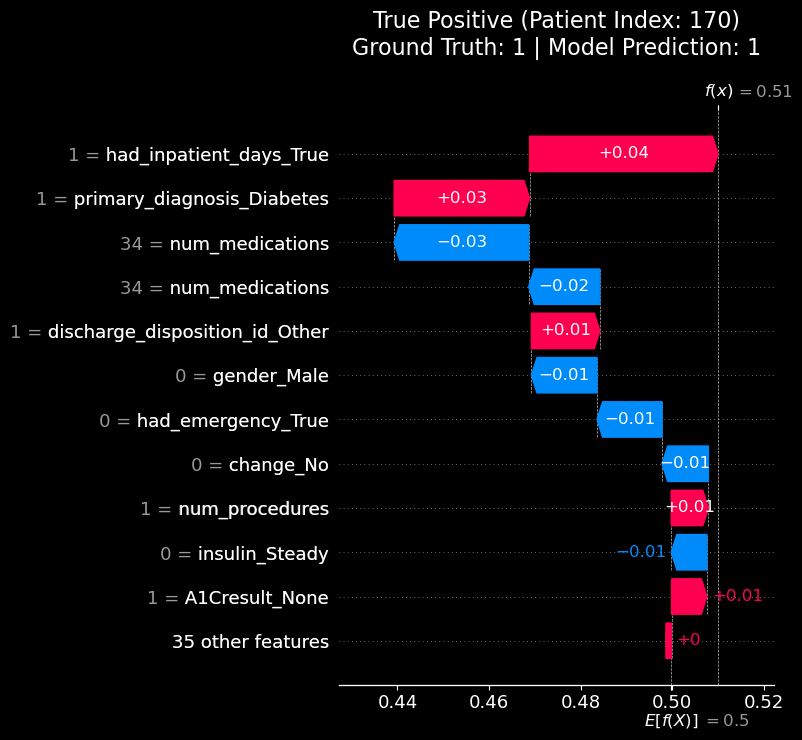

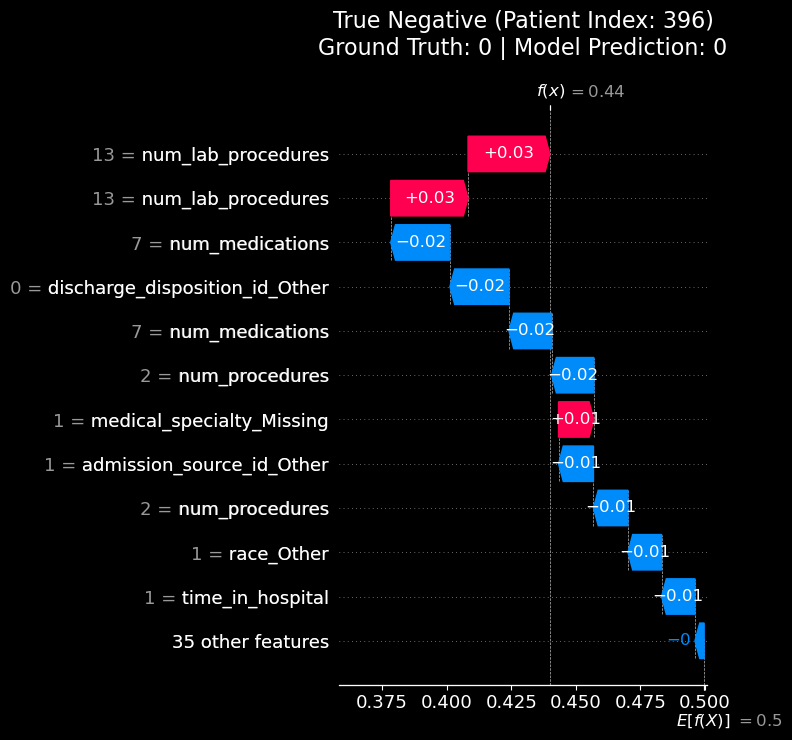

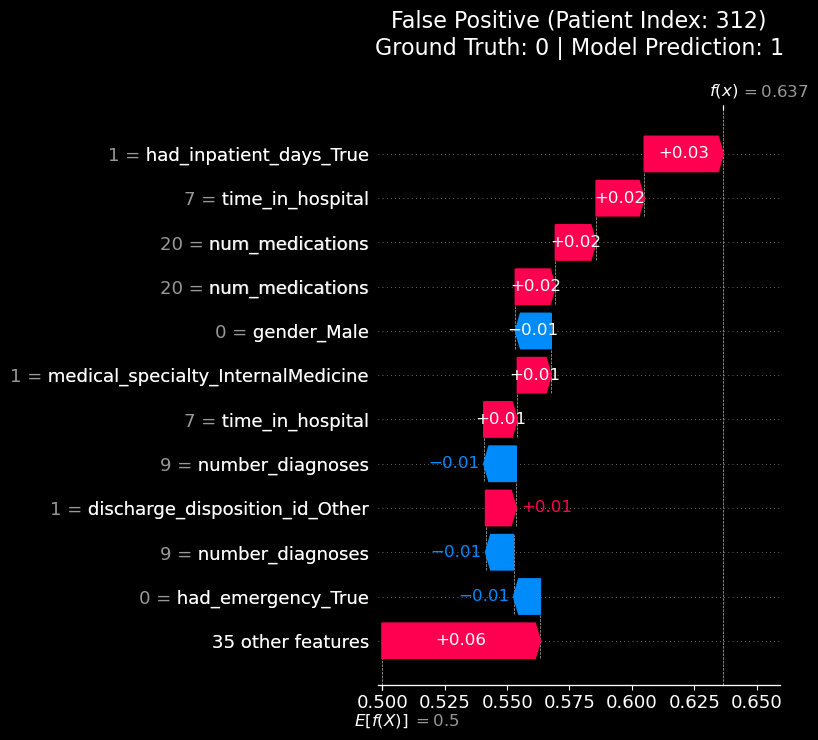

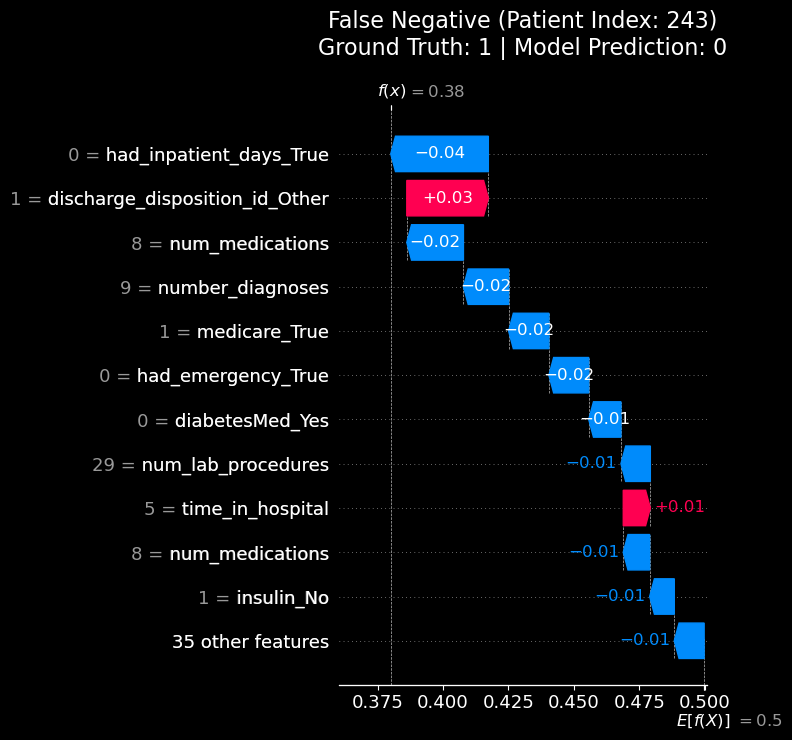

In [9]:
# Helper to grab a random index from a boolean mask
def get_random_idx(mask):
    indices = np.where(mask)[0]
    return np.random.choice(indices) if len(indices) > 0 else None

# Define masks for the four cases
tp_mask = (y_test.values == 1) & (y_pred == 1)
tn_mask = (y_test.values == 0) & (y_pred == 0)
fp_mask = (y_test.values == 0) & (y_pred == 1)
fn_mask = (y_test.values == 1) & (y_pred == 0)

# Select indices
indices = {
    "True Positive": get_random_idx(tp_mask),
    "True Negative": get_random_idx(tn_mask),
    "False Positive": get_random_idx(fp_mask),
    "False Negative": get_random_idx(fn_mask)
}

# 1. Iterate through your selected indices
for label, idx in indices.items():
    if idx is not None:
        # Create a new, fresh figure for every case
        plt.figure(figsize=(15, 10)) 
        
        # Explain the prediction
        # If multiclass, ensure you slice: sv_new[idx, :, 1]
        shap.plots.waterfall(sv_new[idx], max_display=12, show=False)
        
        # Add metadata title
        plt.title(
            f'{label} (Patient Index: {idx})\n'
            f'Ground Truth: {y_test.values[idx]} | Model Prediction: {y_pred[idx]}', 
            fontsize=16, 
            pad=20
        )
        
        plt.tight_layout()
        plt.show() # This renders the individual figure before moving to the next iteration
    else:
        print(f"Skipping {label}: No patients found in this category.")

## 6. Force Plots — Four Representative Cases

The force plot is a compact alternative to the waterfall. We generate one for each of the four classification outcomes (TP / TN / FP / FN), making it easy to compare how the model decomposes predictions across all quadrants of the confusion matrix. Features in **red** push the output above the base value (toward readmission); features in **blue** push it below (away from readmission). The predicted value sits at the boundary between the two colored groups.

Force plots are well suited for embedding in clinical reports or dashboards where space is limited.

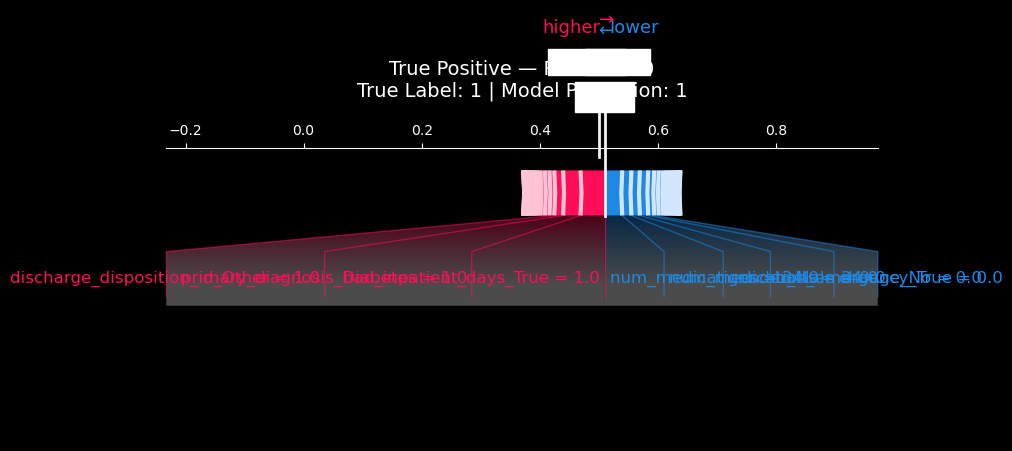

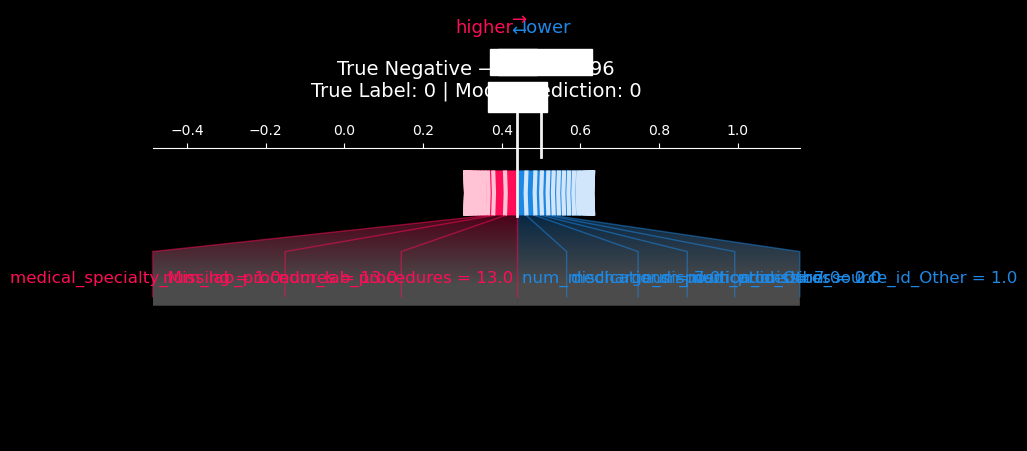

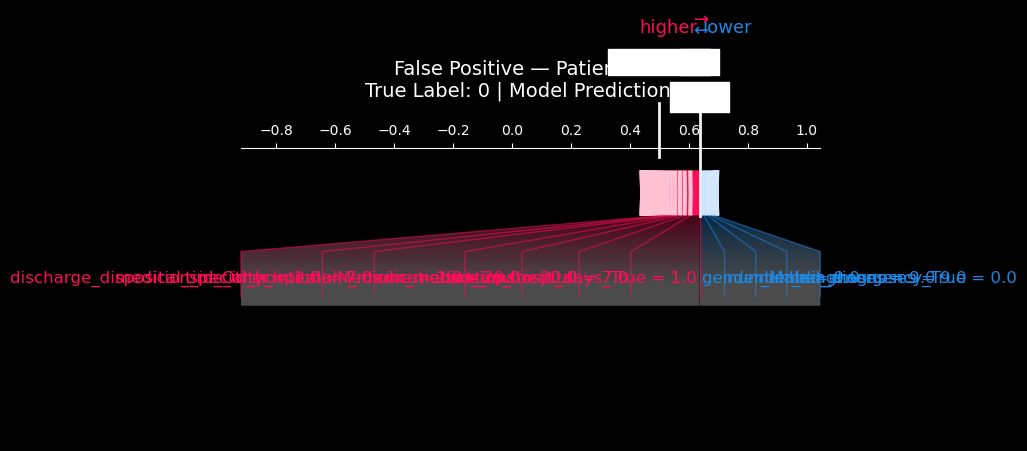

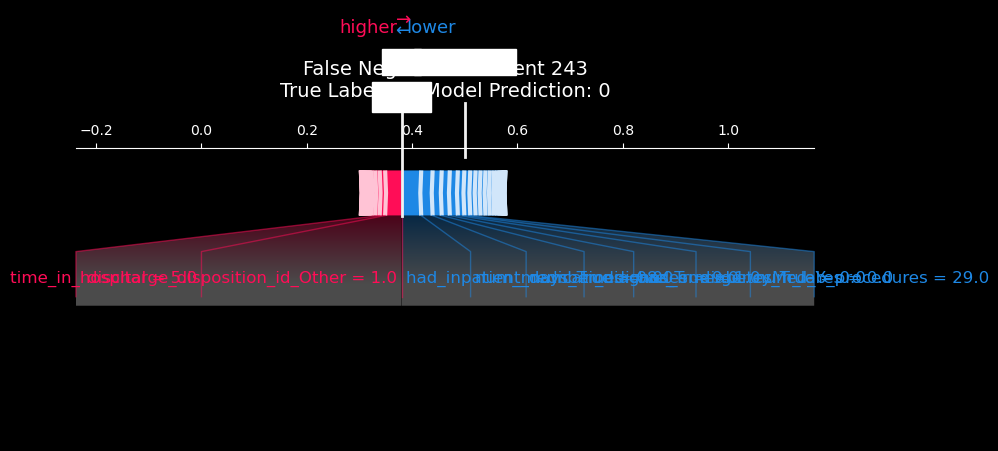

In [10]:
# Assuming 'indices' and 'sv' (SHAP values) are already defined from the previous step
for label, idx in indices.items():
    if idx is not None:
        # shap.force_plot with matplotlib=True handles its own figure creation.
        # We pass show=False so we can add the title before rendering.
        shap.force_plot(
            base_val, 
            sv[idx], 
            X_test.iloc[idx], 
            feature_names=feature_names,
            matplotlib=True, 
            show=False,
            figsize=(10, 5)
        )
        
        # Access the current figure to add the specific title
        plt.title(
            f'{label} — Patient {idx}\n'
            f'True Label: {y_test.values[idx]} | Model Prediction: {y_pred[idx]}',
            fontsize=14,
            pad=20
        )
        
        # Adjust layout and show the individual figure
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping {label}: No patients found.")

## 7. Dependence Plots

A **dependence plot** for feature $j$ shows:

- **X-axis** — the raw value of feature $j$
- **Y-axis** — the SHAP value for feature $j$ (its marginal contribution to the prediction)
- **Color** — a second feature auto-selected by SHAP to reveal interactions (the feature most correlated with the residual variation in SHAP$_j$)

A clean monotone curve means $j$ has a simple, roughly linear effect. Two color-banded streams indicate an **interaction**: the effect of $j$ on the prediction depends on the value of the colored feature.

We plot the six most important features by mean |SHAP|.

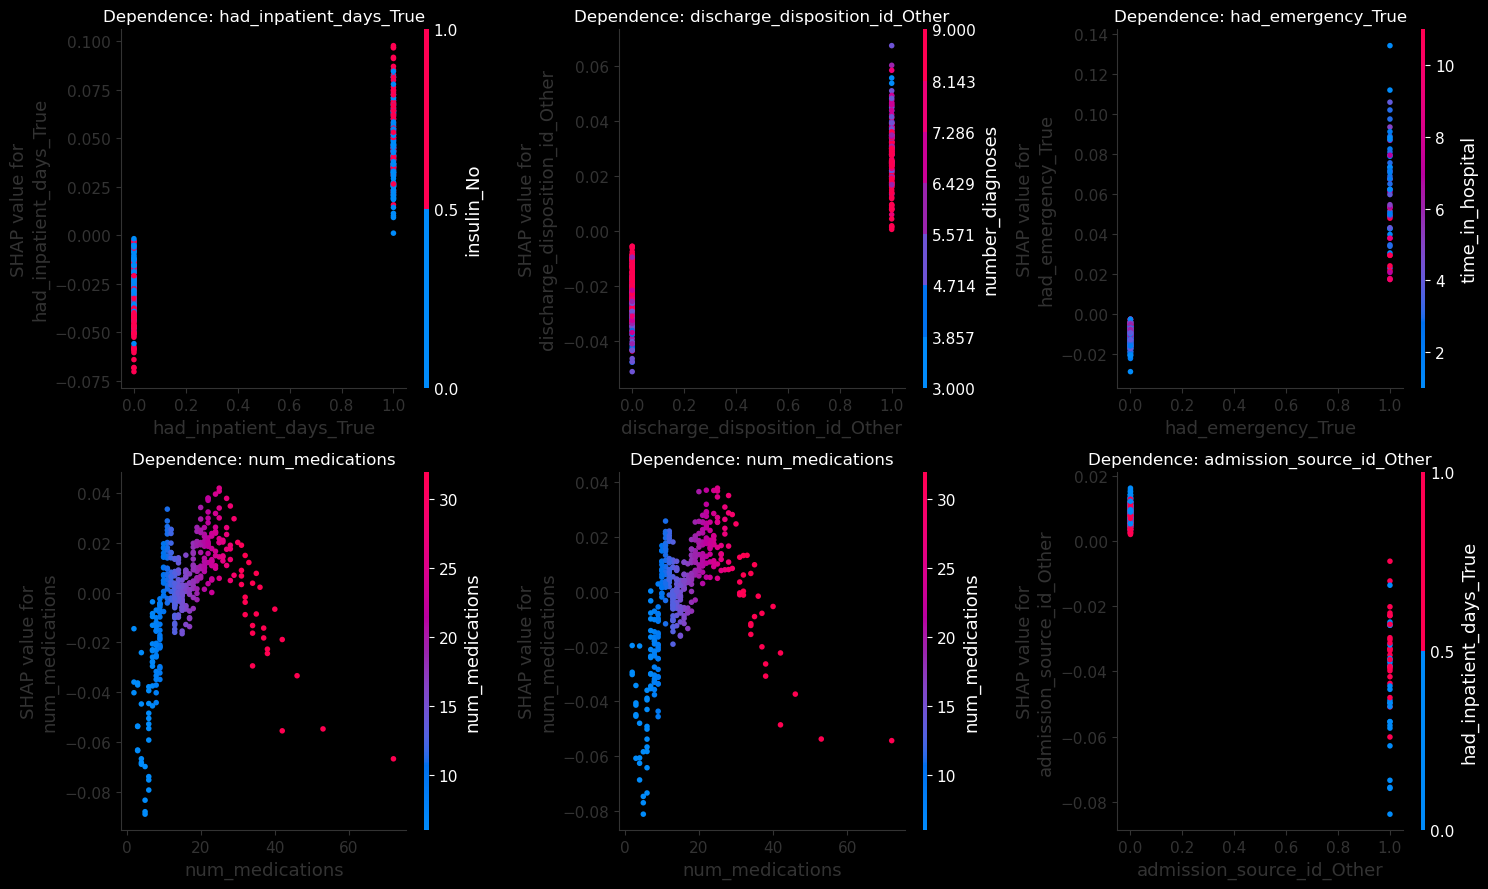

In [11]:
top_feats = np.argsort(-np.abs(sv).mean(axis=0))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for plot_i, feat_idx in enumerate(top_feats):
    ax = axes[plot_i // 3, plot_i % 3]
    shap.dependence_plot(
        int(feat_idx), sv, X_test,
        feature_names=feature_names,
        ax=ax, show=False
    )
    ax.set_title(f'Dependence: {feature_names[feat_idx]}')

plt.tight_layout()
plt.show()

## 8. Decision Plot

The **decision plot** shows the full prediction path for multiple patients simultaneously. Each line is one patient; the x-axis accumulates SHAP contributions feature by feature (sorted top-to-bottom by mean |SHAP|). Lines diverge where patients disagree on a feature's contribution.

Misclassified patients are highlighted in orange — their trajectories often diverge from the correctly-classified majority at a specific feature, pinpointing where the model went wrong.

c:\Users\Graham West\anaconda3\Lib\site-packages\shap\plots\_decision.py:162: UserWarning: Mismatched number of handles and labels: len(handles) = 60 len(labels) = 1
  ax.legend(handles=lines, labels=legend_labels, loc=legend_location)


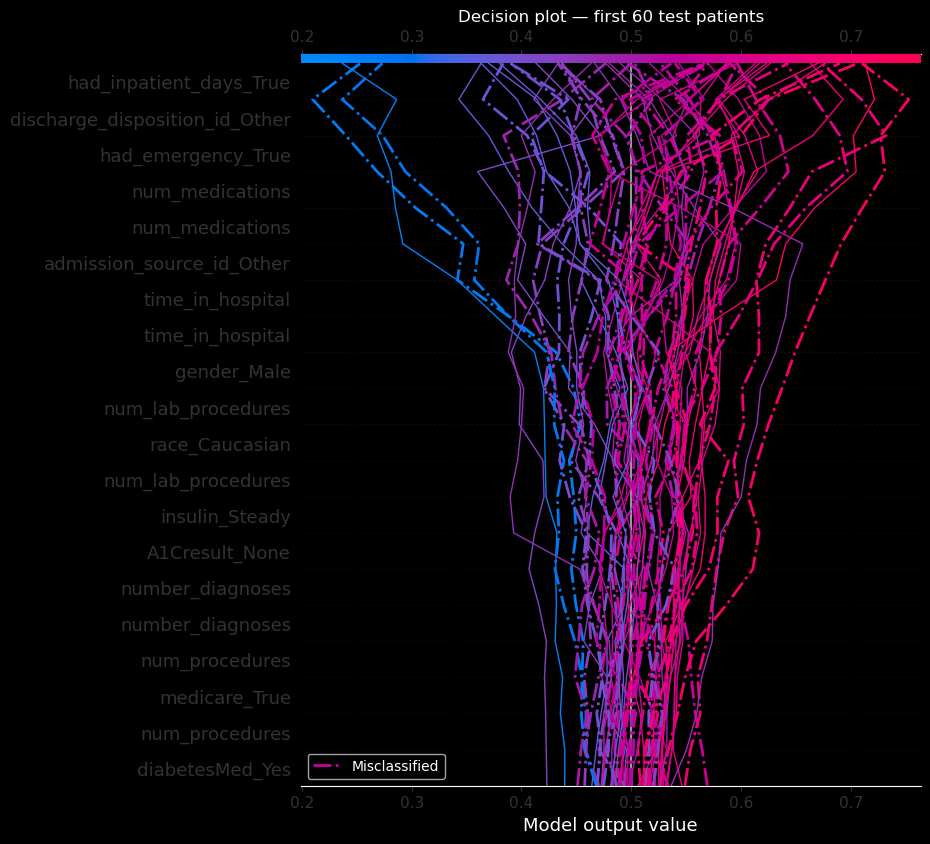

In [12]:
n_show = 60
misclassified = np.where(y_pred[:n_show] != y_test.values[:n_show])[0]

shap.decision_plot(
    base_val,
    sv[:n_show],
    feature_names=feature_names,
    highlight=list(misclassified) if len(misclassified) else None,
    legend_labels=['Misclassified'] if len(misclassified) else None,
    title=f'Decision plot — first {n_show} test patients'
)
plt.show()

## 9. Heatmap Plot

The **heatmap** places patients on the x-axis and features on the y-axis. Each cell is colored by the SHAP value for that (patient, feature) pair. Patients are sorted left-to-right by predicted readmission probability, so the pattern transitions smoothly from low-risk (left) to high-risk (right).

The thin bar at the bottom shows the model output for each patient. Horizontal bands that are consistently red or blue identify features with a strong, consistent directional effect across the entire cohort.

> **Implementation note:** `shap.plots.heatmap` requires the `Explanation` object to carry `feature_names`. This is guaranteed when a **DataFrame** (not a NumPy array) is passed to `explainer()` — the column names propagate automatically.

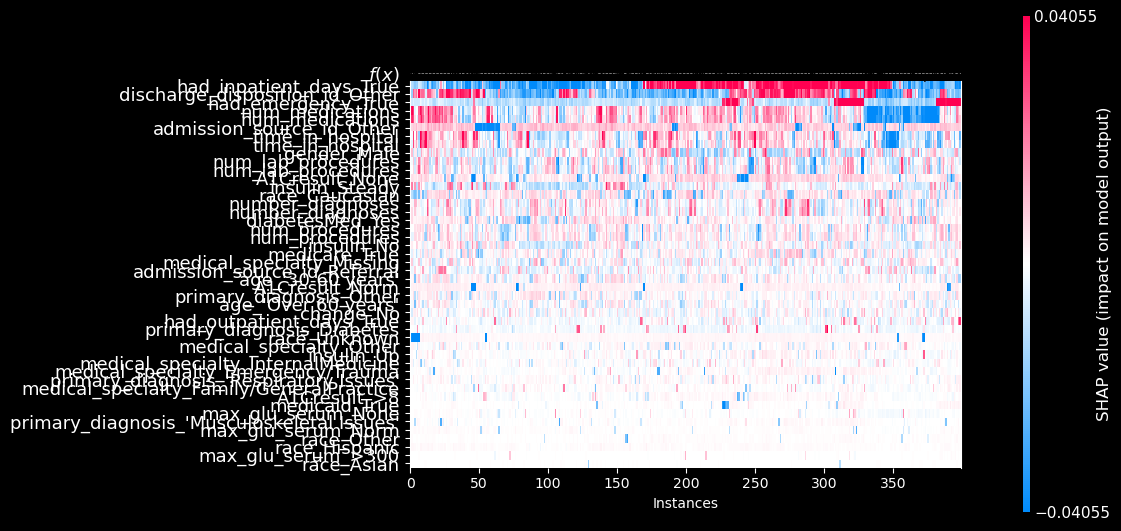

<Axes: xlabel='Instances'>

In [13]:
prob_order = np.argsort(model.predict_proba(X_test)[:, 1])
sv_sorted  = sv_new[prob_order]

shap.plots.heatmap(sv_sorted, max_display=n_feat)

## Summary

| Plot | API | What it shows |
|---|---|---|
| Bar | `shap.plots.bar` | Mean \|SHAP\| — quick global ranking |
| Beeswarm | `shap.plots.beeswarm` | All samples: importance, direction, nonlinearity |
| Dot / Violin | `shap.summary_plot` | Classic API variants; violin cleaner for large $n$ |
| Waterfall | `shap.plots.waterfall` | Step-by-step explanation of one prediction |
| Force (single) | `shap.force_plot` | Compact one-prediction decomposition |
| Force (four cases) | `shap.force_plot` | TN / TP / FP / FN comparison |
| Dependence | `shap.dependence_plot` | Feature effect + auto interaction coloring |
| Decision | `shap.decision_plot` | Prediction paths, misclassified highlighted |
| Heatmap | `shap.plots.heatmap` | Dataset-level SHAP matrix, sorted by output |
| Interaction matrix | `shap_interaction_values` | Pairwise interaction heatmap |
| Interaction summary | `shap.summary_plot(si)` | Main + pairwise interactions |
| Interaction dependence | `shap.dependence_plot((j, k), si)` | Strongest interacting pair |
| SHAP vs. Gini | `spearmanr` + bar charts | Rank agreement between methods |

**SHAP version compatibility note (≥ 0.44):**
- `shap_values(X)` returns `(n, p, 2)` — use `[:, :, 1]` for class 1
- `shap_interaction_values(X)` returns `(n, p, p, 2)` — use `[:, :, :, 1]` for class 1
- `plots.heatmap` requires `feature_names` on the `Explanation` object — feed a DataFrame to `explainer()`
- `force_plot(matplotlib=True)` does **not** support multiple samples — use individual calls

**Core identities:**
- $f(x) = \phi_0 + \sum_j \phi_j$ — predictions decompose exactly
- $\phi_j > 0$ → feature $j$ pushed this prediction above the base rate
- $\phi_j < 0$ → feature $j$ pushed this prediction below the base rate
- $\sum_k \Phi_{jk} = \phi_j$ — interaction values sum to the standard SHAP value